#Import

In [1]:
import numpy as np

import torch
import torch.nn as nn
from torch.autograd import Variable

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
print(device)

cuda:0


#Model

In [3]:
M=128

class Net2D(nn.Module):
    def __init__(self):
        super(Net2D, self).__init__()
        torch.manual_seed(7) # Fix Initial_Parameter
        self.hidden_layer1 = nn.Linear(3,M)
        self.hidden_layer2 = nn.Linear(M,M)
        self.hidden_layer3 = nn.Linear(M,M)
        self.hidden_layer4 = nn.Linear(M,M)
        self.output_layer = nn.Linear(M,1)


    def forward(self, x, y, p):
        inputs = torch.cat([x, y, p],axis=1) # x,y concat
        layer1_out = torch.tanh(self.hidden_layer1(inputs))
        layer2_out = torch.tanh(self.hidden_layer2(layer1_out))
        layer3_out = torch.tanh(self.hidden_layer3(layer2_out))
        layer4_out = torch.tanh(self.hidden_layer4(layer3_out))
        output = self.output_layer(layer4_out) ## For regression, no activation is used in output layer

        return output

# Set loss & optimizer

In [4]:
net_2d = Net2D()
net_2d = net_2d.to(device)
mse_cost_function = torch.nn.MSELoss() # Mean squared error
optimizer = torch.optim.Adam(net_2d.parameters(), lr = 0.001)

# Compute Interior Integral

In [5]:
def f1(x, y, p, net):
    u = (1- x**2 -y**2)*net(x, y, p)

    u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_y = torch.autograd.grad(u.sum(), y, create_graph=True)[0]


    grad_u = (u_x ** 2 + u_y ** 2)**((p - 2) / 2)

    # ∇u의 각 성분에 \|∇u\|^(p-2) 곱하기
    weighted_grad_u_x = grad_u * u_x
    weighted_grad_u_y = grad_u * u_y

    # weighted_grad_u_x와 weighted_grad_u_y의 다이버전스 계산
    div_x = torch.autograd.grad(weighted_grad_u_x.sum(), x, create_graph=True)[0]
    div_y = torch.autograd.grad(weighted_grad_u_y.sum(), y, create_graph=True)[0]

    # p-Laplacian 값 계산
    p_laplacian_value = div_x + div_y
    loss = torch.mean((p_laplacian_value + 2)**2)

    return loss

In [6]:
def f2(x, y, p, net):
    u = (1- x**2 -y**2)*net(x, y, p)

    u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_y = torch.autograd.grad(u.sum(), y, create_graph=True)[0]

    variation = (1/162000)*((1/p)*(((u_x)**2 + (u_y)**2)**(p/2))-2*u).sum()

    return variation

#Set Measure Point(not learn)

In [7]:
# 반지름 1인 원 안에서 임의의 점 생성
r = np.random.uniform(0, 1, 100)  # 0과 1 사이의 값으로 반지름 선택
theta = np.random.uniform(0, 2 * np.pi, 100)  # 0과 2pi 사이에서 각도 선택

# 원 안의 (x, y) 좌표 생성
obx = r * np.cos(theta)
oby = r * np.sin(theta)
obp = np.linspace(1.5, 6, 100)

# 3D meshgrid 생성
ms_x, ms_y, ms_p = np.meshgrid(obx, oby, obp)

# 1D 배열로 변환
obx1 = np.ravel(ms_x).reshape(-1, 1)
oby1 = np.ravel(ms_y).reshape(-1, 1)
obp1 = np.ravel(ms_p).reshape(-1, 1)

# 조건 적용: x^2 + y^2 <= 1
mask = (obx1**2 + oby1**2 <= 1).flatten()
filtered_obx1 = obx1[mask]
filtered_oby1 = oby1[mask]
filtered_obp1 = obp1[mask]

ob_x = Variable(torch.from_numpy(filtered_obx1).float(), requires_grad=True).to(device)
ob_y = Variable(torch.from_numpy(filtered_oby1).float(), requires_grad=True).to(device)
ob_p = Variable(torch.from_numpy(filtered_obp1).float(), requires_grad=True).to(device)

iterations = 20000
previous_validation_loss = 99999999.0

error_list1=[] # for DRM
error_list2=[] # for PINN
error_list3=[] # for MIX
loss_list1 = []  # for DRM
loss_list2 = []  # for PINN
loss_list3 = []  # for MIX

theta_collocation = np.linspace(0, 2 * np.pi, 90)

# 원 위의 (x, y) 좌표 생성
x_collocation = np.cos(theta_collocation)
y_collocation = np.sin(theta_collocation)
p_collocation = np.random.uniform(1.5, 6, 20)

x_grid, y_grid, p_grid = np.meshgrid(x_collocation, y_collocation, p_collocation, indexing='ij')

x_combined = x_grid.ravel().reshape(-1, 1)
y_combined = y_grid.ravel().reshape(-1, 1)
p_combined = p_grid.ravel().reshape(-1, 1)


pt_x_collocation = Variable(torch.from_numpy(x_combined).float(), requires_grad=True).to(device)
pt_y_collocation = Variable(torch.from_numpy(y_combined).float(), requires_grad=True).to(device)
pt_p_collocation = Variable(torch.from_numpy(p_combined).float(), requires_grad=True).to(device)

#DRM

In [8]:
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero

    drm = f2(pt_x_collocation, pt_y_collocation, pt_p_collocation, net_2d)

    drm.backward() # This is for computing gradients using backward propagation
    optimizer.step() # Using Adam


    # 100 에포크마다 손실 값을 출력
    if epoch % 50 == 0:
        pt_u = (1 - (ob_x)**2 -(ob_y)**2)*net_2d(ob_x,ob_y,ob_p)

        solution = ((ob_p-1)/ob_p)*(1-((ob_x)**2 +(ob_y)**2))**(ob_p/(2*(ob_p-1)))

        error_drm = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch : ",epoch)
        print("drm_loss : ",drm.item())
        print("Relative L2 error:", error_drm)
        print("---------------------------------------------------")

        loss_list1.append(drm.item())
        error_list1.append(error_drm.item())

net_drm=net_2d

Epoch :  0
drm_loss :  0.01817738078534603
Relative L2 error: tensor(0.7259, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  50
drm_loss :  -0.09478842467069626
Relative L2 error: tensor(0.4070, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  100
drm_loss :  -0.10993405431509018
Relative L2 error: tensor(0.4038, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  150
drm_loss :  -0.11482544988393784
Relative L2 error: tensor(0.3955, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  200
drm_loss :  -0.11895498633384705
Relative L2 error: tensor(0.3971, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  250
drm_loss :  -0.12369420379400253
Relative L2 error: tensor(0.3959, device='cuda:0', grad_fn=<PowBackward0>)
------------------

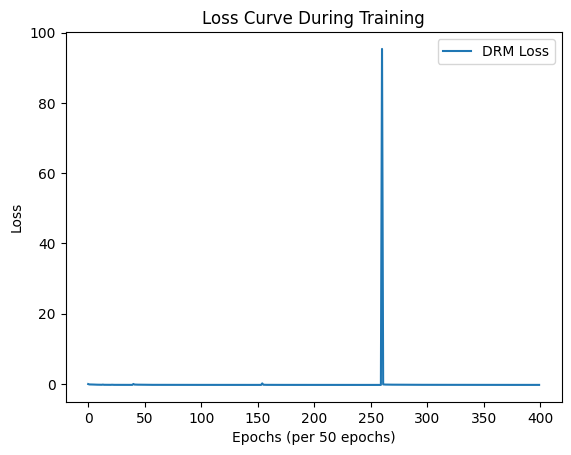

In [9]:
import matplotlib.pyplot as plt

plt.plot(loss_list1, label='DRM Loss')

plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

plt.legend()

plt.show()

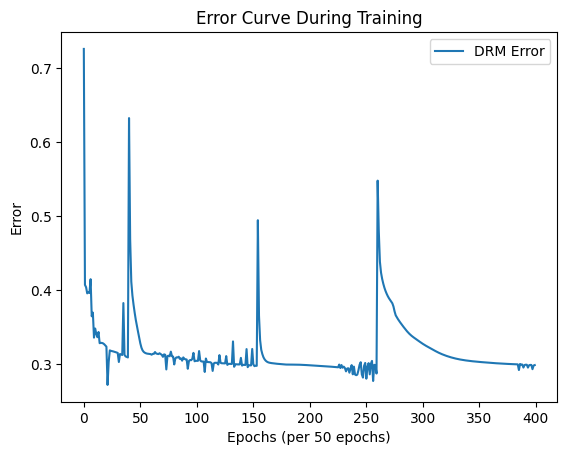

In [10]:
import matplotlib.pyplot as plt

plt.plot(error_list1, label='DRM Error')

plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()

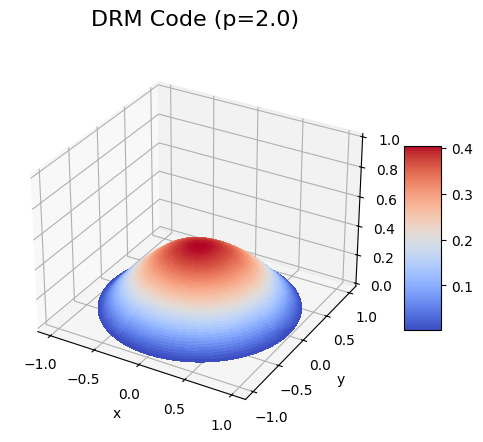

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 2.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_drm(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("DRM Code (p=2.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


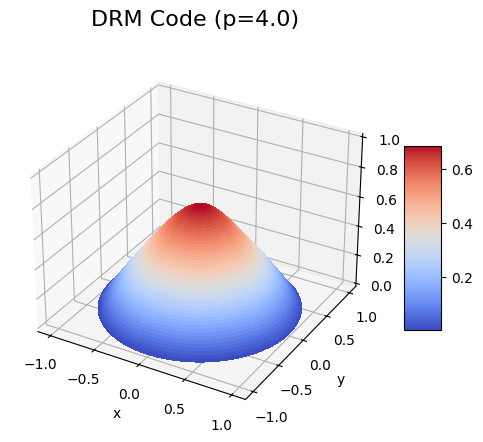

In [12]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 4.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_drm(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("DRM Code (p=4.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


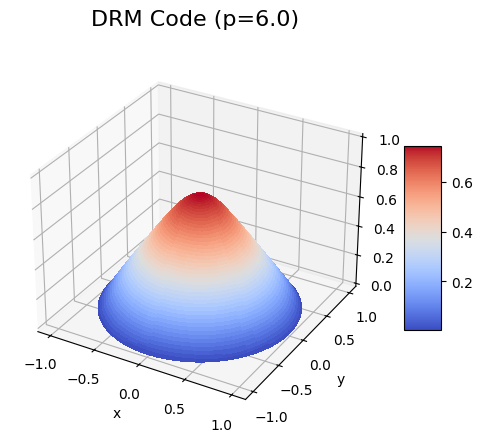

In [13]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 6.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_drm(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("DRM Code (p=6.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


#PINN

In [ ]:
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero

    pinn = f1(pt_x_collocation, pt_y_collocation, pt_p_collocation, net_2d)

    pinn.backward() # This is for computing gradients using backward propagation
    optimizer.step() # Using Adam

    # 100 에포크마다 손실 값을 출력
    if epoch % 50 == 0:
        pt_u = (1 - (ob_x)**2 -(ob_y)**2)*net_2d(ob_x,ob_y,ob_p)

        solution = ((ob_p-1)/ob_p)*(1-((ob_x)**2 +(ob_y)**2))**(ob_p/(2*(ob_p-1)))

        error_pinn = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch : ",epoch)
        print("pinn_loss : ",pinn.item())
        print("Relative L2 error:", error_pinn)
        print("---------------------------------------------------")

        loss_list2.append(pinn.item())
        error_list2.append(error_pinn.item())

net_pinn=net_2d

Epoch :  0
pinn_loss :  155.42808532714844
Relative L2 error: tensor(0.8580, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  50
pinn_loss :  38.136497497558594
Relative L2 error: tensor(1.6878, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  100
pinn_loss :  22.568925857543945
Relative L2 error: tensor(1.5780, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  150
pinn_loss :  15.91886043548584
Relative L2 error: tensor(1.4790, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  200
pinn_loss :  14.247466087341309
Relative L2 error: tensor(1.4499, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  250
pinn_loss :  13.036898612976074
Relative L2 error: tensor(1.4261, device='cuda:0', grad_fn=<PowBackward0>)
------------------------

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list2, label='PINN Loss')

plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_list2, label='PINN Error')

plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 2.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_pinn(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("PINN Code (p=2.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 4.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_pinn(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("PINN Code (p=4.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 6.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_pinn(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("PINN Code (p=6.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


#MIX

In [ ]:
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero

    f1_out = f1(pt_x_collocation, pt_y_collocation, pt_p_collocation, net_2d)
    f2_out = f2(pt_x_collocation, pt_y_collocation, pt_p_collocation, net_2d)

    f_out = 0.7 * f1_out + 0.3 * f2_out

    # print(f_out)

    ##----------------------------Compute Loss & Backpropagation-------------------------------##
    mix = 0.5*f_out

    mix.backward() # This is for computing gradients using backward propagation
    optimizer.step() # Using Adam


    # 100 에포크마다 손실 값을 출력
    if epoch % 50 == 0:
        pt_u = (1 - (ob_x)**2 -(ob_y)**2)*net_2d(ob_x,ob_y,ob_p)

        solution = ((ob_p-1)/ob_p)*(1-((ob_x)**2 +(ob_y)**2))**(ob_p/(2*(ob_p-1)))

        error_mix = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch : ",epoch)
        print("mix_loss : ",mix.item())
        print("Relative L2 error:", error_mix)
        print("---------------------------------------------------")

        loss_list3.append(mix.item())
        error_list3.append(error_mix.item())

net_mix=net_2d

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list3, label='MIX Loss')

plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_list3, label='MIX Error')

plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 2.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_mix(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("Hybrid Code (p=2.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 4.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_mix(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("Hybrid Code (p=4.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# x와 y가 원 경계 (x^2 + y^2 <= 1)를 만족하도록 설정
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linspace(0, 1, 50)
theta, r = np.meshgrid(theta, r)
x = r * np.cos(theta)
y = r * np.sin(theta)

# p 값을 변경 가능한 형태로 설정
p_value = 6.0  # 원하는 p 값을 여기에 설정
x_flat = np.ravel(x).reshape(-1, 1)
y_flat = np.ravel(y).reshape(-1, 1)
p = np.full_like(x_flat, p_value)

# PyTorch Variable 생성
pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_p = Variable(torch.from_numpy(p).float(), requires_grad=True).to(device)

# 네트워크 예측 및 결과를 2D 형상으로 변환
Predict = (1 - pt_x**2 - pt_y**2) * net_mix(pt_x, pt_y, pt_p)
Predict = Predict.data.cpu().numpy()
PR_u = Predict.reshape(x.shape)

# 3D 표면 그래프 생성
surf = ax.plot_surface(x, y, PR_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


# 그래프 제목과 라벨 설정
ax.set_title("Hybrid Code (p=6.0)", fontsize=16, pad=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
ax.set_zlim(0, 1)

plt.show()


#Conclusion

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

ax = fig.add_subplot(projection='3d')

p = 2

y_np = np.linspace(-1, 1, 500)
p_np = np.ones_like(y_np)
x_np = np.zeros_like(y_np)


x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
p = Variable(torch.from_numpy(p_np).float().unsqueeze(1), requires_grad=True).to(device)


# f(x, y) 계산
z_PINN = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_pinn(x, y, p)).cpu().detach().numpy()
z_DRM = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_drm(x, y, p)).cpu().detach().numpy()
z_Mix = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_mix(x, y, p)).cpu().detach().numpy()

# 2D 그래프로 시각화
plt.figure(figsize=(8, 6))
plt.plot(y_np, z_PINN, label=f'PINN')
plt.plot(y_np, z_DRM, label=f'DRM')
plt.plot(y_np, z_Mix, label=f'Mix')

plt.title("| True U - Pred U |")
plt.xlabel("y")
plt.ylabel("f(x, y)")
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

ax = fig.add_subplot(projection='3d')

p = 4

y_np = np.linspace(-1, 1, 500)
p_np = np.ones_like(y_np)
x_np = np.zeros_like(y_np)


x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
p = Variable(torch.from_numpy(p_np).float().unsqueeze(1), requires_grad=True).to(device)


# f(x, y) 계산
z_PINN = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_pinn(x, y, p)).cpu().detach().numpy()
z_DRM = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_drm(x, y, p)).cpu().detach().numpy()
z_Mix = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_mix(x, y, p)).cpu().detach().numpy()

# 2D 그래프로 시각화
plt.figure(figsize=(8, 6))
plt.plot(y_np, z_PINN, label=f'PINN')
plt.plot(y_np, z_DRM, label=f'DRM')
plt.plot(y_np, z_Mix, label=f'Mix')

plt.title("| True U - Pred U |")
plt.xlabel("y")
plt.ylabel("f(x, y)")
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

ax = fig.add_subplot(projection='3d')

p = 6

y_np = np.linspace(-1, 1, 500)
p_np = np.ones_like(y_np)
x_np = np.zeros_like(y_np)


x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
p = Variable(torch.from_numpy(p_np).float().unsqueeze(1), requires_grad=True).to(device)


# f(x, y) 계산
z_PINN = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_pinn(x, y, p)).cpu().detach().numpy()
z_DRM = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_drm(x, y, p)).cpu().detach().numpy()
z_Mix = torch.abs( ((p-1)/p)*(1-y**(p/(p-1))) - (1 - y**2) * net_mix(x, y, p)).cpu().detach().numpy()

# 2D 그래프로 시각화
plt.figure(figsize=(8, 6))
plt.plot(y_np, z_PINN, label=f'PINN')
plt.plot(y_np, z_DRM, label=f'DRM')
plt.plot(y_np, z_Mix, label=f'Mix')

plt.title("| True U - Pred U |")
plt.xlabel("y")
plt.ylabel("f(x, y)")
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()
